<a href="https://colab.research.google.com/github/harishmuh/Deep-Learning_study/blob/main/02_mnist_classification_using_CNN_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Handwritten digits classification using CNN**

---

**Context**

Previously, we had classified the handwritten digits using Multi Layer Perceptron (MLP) model in this [notebook](https://github.com/harishmuh/Deep-Learning_study/blob/main/01_mnist_classification_using_MLP.ipynb).

In this tutorial, we will classify handwritten digit using the CNN model with Pytorch.  

**Convolutional Neural Network (CNN)**

A Convolutional Neural Network (CNN) is a type of deep neural network designed primarily for processing grid-structured data such as images. It uses convolutional layers to automatically extract spatial features (e.g., edges, textures, shapes) through local connections and shared weights, making it more efficient than fully connected networks for visual tasks.

**About Handwritten digits - MNIST dataset**

![eight](https://user-images.githubusercontent.com/51207580/59979373-bc052480-9604-11e9-85b8-464367fdc891.png)

Dataset Characteristics:

* 70,000 grayscale images

    * 60,000 training images

    * 10,000 test images

* Image size: 28 × 28 pixels (784 total pixels)

* Pixel range: 0–255

* 10 labels/classes (digits 0–9)

**Initial setup**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Set random seeds for reproducibility
torch.manual_seed(42)

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define hyperparameters
num_classes = 10
learning_rate = 0.001
batch_size = 100
num_epochs = 10

In [2]:
# Load MNIST dataset
train_dataset = datasets.MNIST(
    root="data", train=True, transform=transforms.ToTensor(), download=True
)
test_dataset = datasets.MNIST(
    root="data", train=False, transform=transforms.ToTensor()
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.65MB/s]


In [3]:
# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [4]:
# Define CNN model
class CNN(nn.Module):
    # How do we extract features
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()
        self.features = nn.Sequential(
            # Convolution layer: input channel, output_channel, kernel_size, stride, padding
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            # Activation function
            nn.ReLU(),
            # Max pooling layer -> get maximum value
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Convolution layer
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            # Activation function
            nn.ReLU(),
            # Max Pooling layer
            nn.MaxPool2d(kernel_size=2, stride=2),
        ) # Output : B, 32, 7, 7
        self.classifier = nn.Linear(32 * 7 * 7, num_classes)
    # def forward will be processed after we call the nn.Module
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x #B, num_class

model = CNN().to(device)

In [5]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

**Model training**

In [6]:
# Function for model training
def train(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(data_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(data_loader), 100.0 * correct / total

**Model evaluation**

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Function for model evaluation
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    predicted_labels = []
    true_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            predicted_labels.extend(predicted.tolist())
            true_labels.extend(labels.tolist())

    precision = precision_score(true_labels, predicted_labels, average="macro")
    recall = recall_score(true_labels, predicted_labels, average="macro")
    f1 = f1_score(true_labels, predicted_labels, average="macro")

    return (
        total_loss / len(data_loader),
        100.0 * correct / total,
        precision,
        recall,
        f1,
        predicted_labels,
        true_labels,
    )

In [8]:
# Training loop
for epoch in range(num_epochs):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc, precision, recall, f1, predicted_labels, true_labels = evaluate(
        model, test_loader, criterion, device
    )

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, "
        f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%, "
        f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}"
    )

Epoch [1/10], Train Loss: 0.3258, Train Acc: 90.45%, Test Loss: 0.0959, Test Acc: 97.18%, Precision: 0.9719, Recall: 0.9718, F1: 0.9717
Epoch [2/10], Train Loss: 0.0855, Train Acc: 97.47%, Test Loss: 0.0627, Test Acc: 98.01%, Precision: 0.9804, Recall: 0.9802, F1: 0.9802
Epoch [3/10], Train Loss: 0.0614, Train Acc: 98.18%, Test Loss: 0.0511, Test Acc: 98.30%, Precision: 0.9829, Recall: 0.9830, F1: 0.9829
Epoch [4/10], Train Loss: 0.0512, Train Acc: 98.41%, Test Loss: 0.0430, Test Acc: 98.66%, Precision: 0.9864, Recall: 0.9866, F1: 0.9865
Epoch [5/10], Train Loss: 0.0435, Train Acc: 98.67%, Test Loss: 0.0402, Test Acc: 98.61%, Precision: 0.9860, Recall: 0.9861, F1: 0.9860
Epoch [6/10], Train Loss: 0.0386, Train Acc: 98.82%, Test Loss: 0.0390, Test Acc: 98.67%, Precision: 0.9868, Recall: 0.9865, F1: 0.9866
Epoch [7/10], Train Loss: 0.0334, Train Acc: 98.95%, Test Loss: 0.0416, Test Acc: 98.53%, Precision: 0.9850, Recall: 0.9853, F1: 0.9851
Epoch [8/10], Train Loss: 0.0305, Train Acc: 99.

**Confusion matrix**

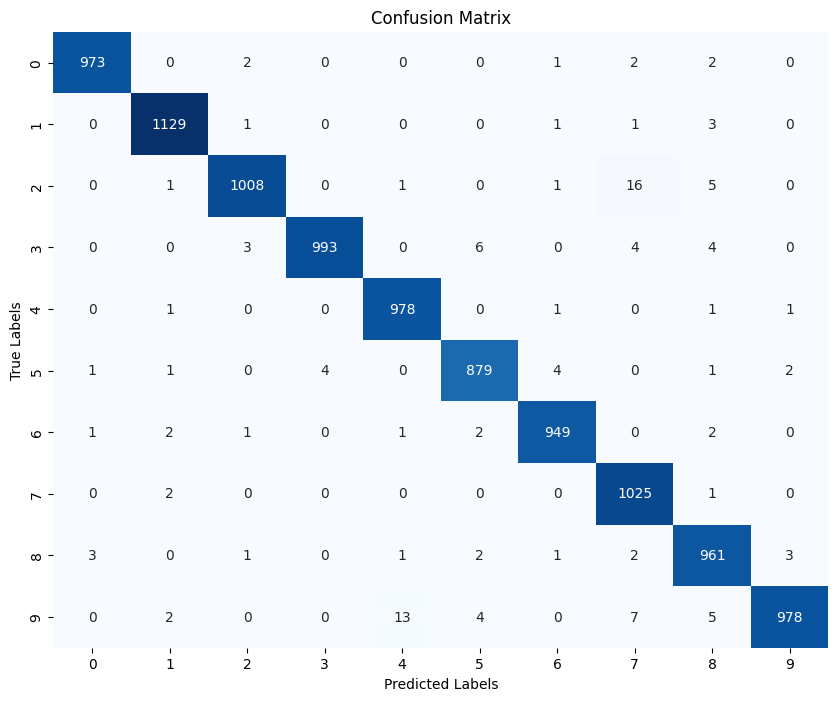

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

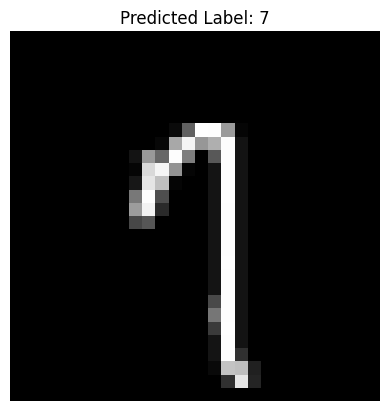

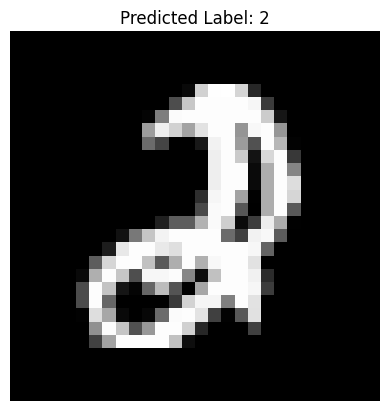

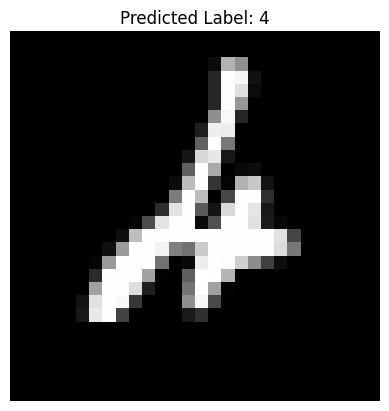

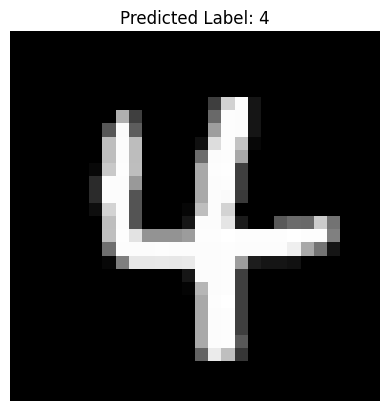

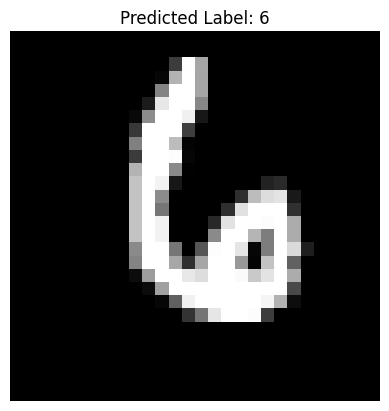

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Function to display the image and predicted label
def show_prediction(image, predicted_label):
    plt.imshow(image.squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"Predicted Label: {predicted_label}")
    plt.show()

# Specify the number of sample images to test
num_samples = 5

# Select random sample images from the test set
sample_indices = np.random.choice(len(test_dataset), num_samples, replace=False)

for index in sample_indices:
    sample_image, sample_label = test_dataset[index]
    sample_image = sample_image.to(device).unsqueeze(0)

    # Make the prediction
    model.eval()
    with torch.no_grad():
        output = model(sample_image)
        _, predicted = torch.max(output.data, 1)

    # Convert the tensor to a numpy array
    sample_image = sample_image.cpu().squeeze().numpy()

    # Display the sample image and predicted label
    show_prediction(sample_image, predicted.item())